<a href="https://www.kaggle.com/code/haymig/superstore?scriptVersionId=312758564" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Pandas Hands-On Project: Superstore Dataset Analysis


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('ggplot')
%matplotlib inline

## Task 1: Load & Explore Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin-1')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (9994, 21)


In [3]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

In [5]:
print("Column names:")
print([df.columns])

Column names:
[Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')]


In [6]:
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Task 2: Data Cleaning

In [7]:
print("Missing values in each column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values in each column:
Series([], dtype: int64)

Total missing values: 0


In [8]:
# Handle missing data

missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values:")
print(missing_percentage[missing_percentage > 0])

# Drop rows with missing values if any
df_cleaned = df.dropna()
print(f"\nRows after cleaning: {len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

Percentage of missing values:
Series([], dtype: float64)

Rows after cleaning: 9994
Rows removed: 0


In [9]:
# Convert date columns to datetime
date_columns = ['Order Date', 'Ship Date']

for col in date_columns:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_datetime(df_cleaned[col])
        print(f"{col} converted to datetime")

print("\nData types after conversion:")
print(df_cleaned.dtypes)

Order Date converted to datetime
Ship Date converted to datetime

Data types after conversion:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


## Task 3: Feature Engineering

In [10]:
# Extract Month and Year from Order Date
df_cleaned['Order Year'] = df_cleaned['Order Date'].dt.year
df_cleaned['Order Month'] = df_cleaned['Order Date'].dt.month
df_cleaned['Order Month Name'] = df_cleaned['Order Date'].dt.month_name()
df_cleaned['Order Quarter'] = df_cleaned['Order Date'].dt.quarter

print("Date features created successfully!")
print(df_cleaned[['Order Date', 'Order Year', 'Order Month', 'Order Month Name', 'Order Quarter']].head())

Date features created successfully!
  Order Date  Order Year  Order Month Order Month Name  Order Quarter
0 2016-11-08        2016           11         November              4
1 2016-11-08        2016           11         November              4
2 2016-06-12        2016            6             June              2
3 2015-10-11        2015           10          October              4
4 2015-10-11        2015           10          October              4


In [11]:
# Create new column: Profit Margin (Profit/Sales ratio)
df_cleaned['Profit Margin'] = (df_cleaned['Profit'] / df_cleaned['Sales']) * 100

# Create new column: Discount Category
df_cleaned['Discount Category'] = pd.cut(df_cleaned['Discount'], 
                                          bins=[-0.01, 0, 0.1, 0.2, 1], 
                                          labels=['No Discount', 'Low', 'Medium', 'High'])

print("New features created!")
print(df_cleaned[['Sales', 'Profit', 'Profit Margin', 'Discount', 'Discount Category']].head(10))

New features created!
      Sales    Profit  Profit Margin  Discount Discount Category
0  261.9600   41.9136          16.00      0.00       No Discount
1  731.9400  219.5820          30.00      0.00       No Discount
2   14.6200    6.8714          47.00      0.00       No Discount
3  957.5775 -383.0310         -40.00      0.45              High
4   22.3680    2.5164          11.25      0.20            Medium
5   48.8600   14.1694          29.00      0.00       No Discount
6    7.2800    1.9656          27.00      0.00       No Discount
7  907.1520   90.7152          10.00      0.20            Medium
8   18.5040    5.7825          31.25      0.20            Medium
9  114.9000   34.4700          30.00      0.00       No Discount


In [12]:
# Verify Profit Margin logic
print("Verifying Profit Margin calculation:")
sample = df_cleaned[['Sales', 'Profit', 'Profit Margin']].head(10)
sample['Calculated Margin'] = (sample['Profit'] / sample['Sales']) * 100
sample['Match'] = np.isclose(sample['Profit Margin'], sample['Calculated Margin'])
print(sample)
print(f"\nAll calculations correct: {sample['Match'].all()}")

Verifying Profit Margin calculation:
      Sales    Profit  Profit Margin  Calculated Margin  Match
0  261.9600   41.9136          16.00              16.00   True
1  731.9400  219.5820          30.00              30.00   True
2   14.6200    6.8714          47.00              47.00   True
3  957.5775 -383.0310         -40.00             -40.00   True
4   22.3680    2.5164          11.25              11.25   True
5   48.8600   14.1694          29.00              29.00   True
6    7.2800    1.9656          27.00              27.00   True
7  907.1520   90.7152          10.00              10.00   True
8   18.5040    5.7825          31.25              31.25   True
9  114.9000   34.4700          30.00              30.00   True

All calculations correct: True


## Task 4: GroupBy & Aggregation

In [13]:
# Calculate total sales by category
sales_by_category = df_cleaned.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Total Sales by Category:")
print(sales_by_category)
print(f"\nTotal: ${sales_by_category.sum():,.2f}")

Total Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Total: $2,297,200.86


In [14]:
# Calculate total profit by region
profit_by_region = df_cleaned.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("Total Profit by Region:")
print(profit_by_region)
print(f"\nTotal: ${profit_by_region.sum():,.2f}")

Total Profit by Region:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

Total: $286,397.02


In [15]:
# Identify top 5 customers based on sales
top_customers = df_cleaned.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Customers by Sales:")
print(top_customers)
print(f"\nTop 5 customers contribute: ${top_customers.sum():,.2f}")

Top 5 Customers by Sales:
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

Top 5 customers contribute: $88,281.80


In [16]:
# Analyze sales trends over time (monthly)
monthly_sales = df_cleaned.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Order Year'].astype(str) + '-' + monthly_sales['Order Month'].astype(str).str.zfill(2)
print("Monthly Sales Trends:")
print(monthly_sales.head(15))

Monthly Sales Trends:
    Order Year  Order Month       Sales Year-Month
0         2014            1  14236.8950    2014-01
1         2014            2   4519.8920    2014-02
2         2014            3  55691.0090    2014-03
3         2014            4  28295.3450    2014-04
4         2014            5  23648.2870    2014-05
5         2014            6  34595.1276    2014-06
6         2014            7  33946.3930    2014-07
7         2014            8  27909.4685    2014-08
8         2014            9  81777.3508    2014-09
9         2014           10  31453.3930    2014-10
10        2014           11  78628.7167    2014-11
11        2014           12  69545.6205    2014-12
12        2015            1  18174.0756    2015-01
13        2015            2  11951.4110    2015-02
14        2015            3  38726.2520    2015-03


## Task 5: Pivot Tables

In [17]:
# Pivot table: Sales by Category and Region
pivot_category_region = pd.pivot_table(df_cleaned, 
                                        values='Sales', 
                                        index='Category', 
                                        columns='Region', 
                                        aggfunc='sum', 
                                        margins=True)
print("Sales by Category and Region:")
print(pivot_category_region)

Sales by Category and Region:
Region               Central        East       South         West  \
Category                                                            
Furniture        163797.1638  208291.204  117298.684  252612.7435   
Office Supplies  167026.4150  205516.055  125651.313  220853.2490   
Technology       170416.3120  264973.981  148771.908  251991.8320   
All              501239.8908  678781.240  391721.905  725457.8245   

Region                    All  
Category                       
Furniture        7.419998e+05  
Office Supplies  7.190470e+05  
Technology       8.361540e+05  
All              2.297201e+06  


In [18]:
# Pivot table: Sales trends by Segment over time
pivot_segment_time = pd.pivot_table(df_cleaned, 
                                     values='Sales', 
                                     index='Order Year', 
                                     columns='Segment', 
                                     aggfunc='sum')
print("Sales Trends by Segment over Time:")
print(pivot_segment_time)

Sales Trends by Segment over Time:
Segment        Consumer    Corporate  Home Office
Order Year                                       
2014        266096.8126  128434.8737   89715.8118
2015        266535.9333  128757.3069   75239.2688
2016        296863.8992  207106.3618  105235.3370
2017        331904.6999  241847.8244  159462.7309


In [19]:
# Pivot table: Profit by Sub-Category
pivot_subcategory_profit = pd.pivot_table(df_cleaned, 
                                           values='Profit', 
                                           index='Sub-Category', 
                                           aggfunc='sum').sort_values('Profit', ascending=False)
print("Profit by Sub-Category:")
print(pivot_subcategory_profit)

Profit by Sub-Category:
                  Profit
Sub-Category            
Copiers       55617.8249
Phones        44515.7306
Accessories   41936.6357
Paper         34053.5693
Binders       30221.7633
Chairs        26590.1663
Storage       21278.8264
Appliances    18138.0054
Furnishings   13059.1436
Envelopes      6964.1767
Art            6527.7870
Labels         5546.2540
Machines       3384.7569
Fasteners       949.5182
Supplies      -1189.0995
Bookcases     -3472.5560
Tables       -17725.4811


## Task 6: Data Splitting & Merging

In [20]:
# Split dataset into two meaningful DataFrames
# DataFrame 1: Order information
df_orders = df_cleaned[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 
                        'Customer ID', 'Customer Name', 'Segment']].copy()

# DataFrame 2: Product and financial information
df_products = df_cleaned[['Order ID', 'Product ID', 'Category', 'Sub-Category', 
                        'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']].copy()

print(f"Orders DataFrame shape: {df_orders.shape}")
print(f"Products DataFrame shape: {df_products.shape}")
print("\nOrders DataFrame:")
print(df_orders.head())
print("\nProducts DataFrame:")
print(df_products.head())

Orders DataFrame shape: (9994, 7)
Products DataFrame shape: (9994, 9)

Orders DataFrame:
         Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment  
0      Claire Gute   Consumer  
1      Claire Gute   Consumer  
2  Darrin Van Huff  Corporate  
3   Sean O'Donnell   Consumer  
4   Sean O'Donnell   Consumer  

Products DataFrame:
         Order ID       Product ID         Category Sub-Category  \
0  CA-2016-152156  FUR-BO-10001798        Furniture    Bookcases   
1  CA-2016-152156  FUR-CH-10000454        Furniture       Chairs   
2  CA-2016-138688  OFF-LA-10000240  Office Supplies       Labels   

In [21]:
# Merge the DataFrames back
df_merged = pd.merge(df_orders, df_products, on='Order ID', how='inner')
print(f"Merged DataFrame shape: {df_merged.shape}")
print("\nMerged DataFrame:")
print(df_merged.head())

Merged DataFrame shape: (29906, 15)

Merged DataFrame:
         Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
1  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
2  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
3  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
4  CA-2016-138688 2016-06-12 2016-06-16  Second Class    DV-13045   

     Customer Name    Segment       Product ID         Category Sub-Category  \
0      Claire Gute   Consumer  FUR-BO-10001798        Furniture    Bookcases   
1      Claire Gute   Consumer  FUR-CH-10000454        Furniture       Chairs   
2      Claire Gute   Consumer  FUR-BO-10001798        Furniture    Bookcases   
3      Claire Gute   Consumer  FUR-CH-10000454        Furniture       Chairs   
4  Darrin Van Huff  Corporate  OFF-LA-10000240  Office Supplies       Labels   

                                        Product N

In [22]:
# Verify the merge is correct
print("Verification:")
print(f"Original cleaned data rows: {len(df_cleaned)}")
print(f"Merged data rows: {len(df_merged)}")
print(f"Match: {len(df_cleaned) == len(df_merged)}")

# Check if key columns match
original_sales_sum = df_cleaned['Sales'].sum()
merged_sales_sum = df_merged['Sales'].sum()
print(f"\nOriginal total sales: ${original_sales_sum:,.2f}")
print(f"Merged total sales: ${merged_sales_sum:,.2f}")
print(f"Sales match: {np.isclose(original_sales_sum, merged_sales_sum)}")

Verification:
Original cleaned data rows: 9994
Merged data rows: 29906
Match: False

Original total sales: $2,297,200.86
Merged total sales: $7,114,084.73
Sales match: False


## Task 7: Data Visualization

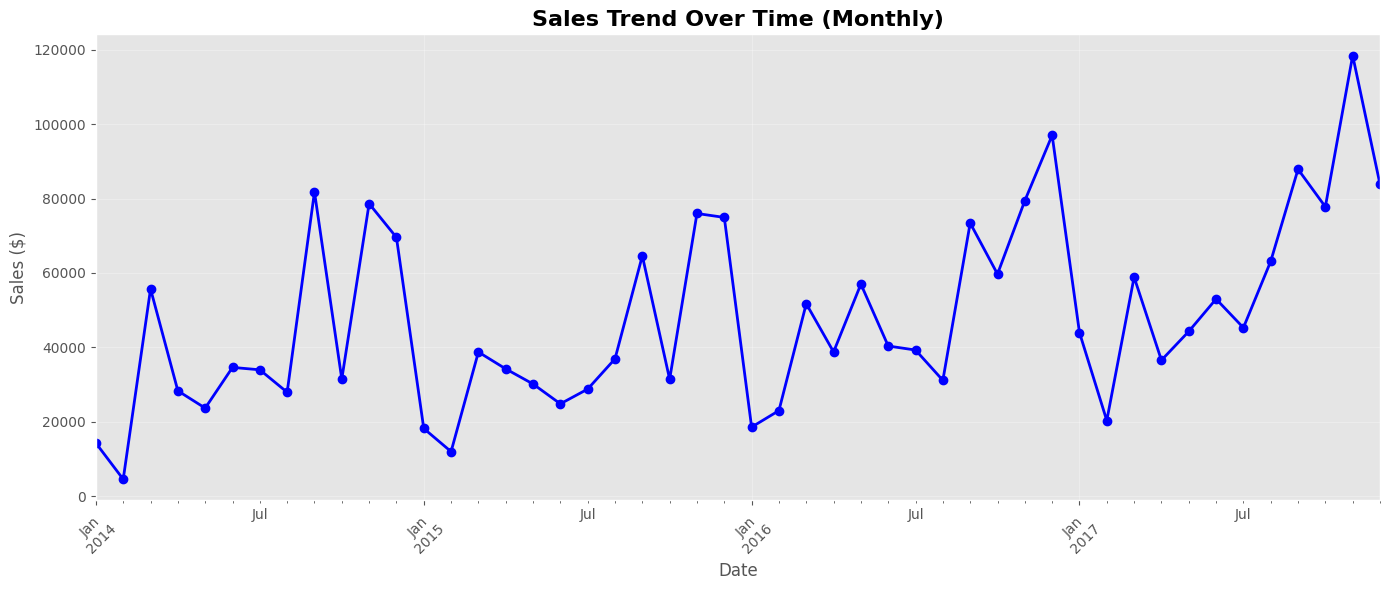

In [23]:
# Line chart: Sales trend over time
plt.figure(figsize=(14, 6))
monthly_sales_plot = df_cleaned.groupby(df_cleaned['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales_plot.plot(kind='line', marker='o', color='blue', linewidth=2)
plt.title('Sales Trend Over Time (Monthly)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

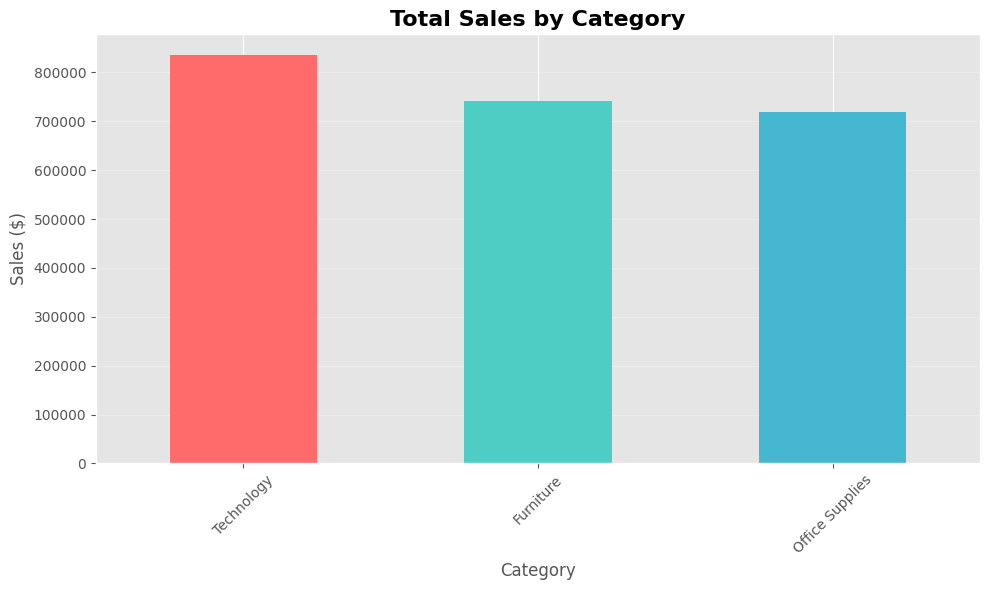

In [24]:
# Bar chart: Sales by Category
plt.figure(figsize=(10, 6))
sales_by_category.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

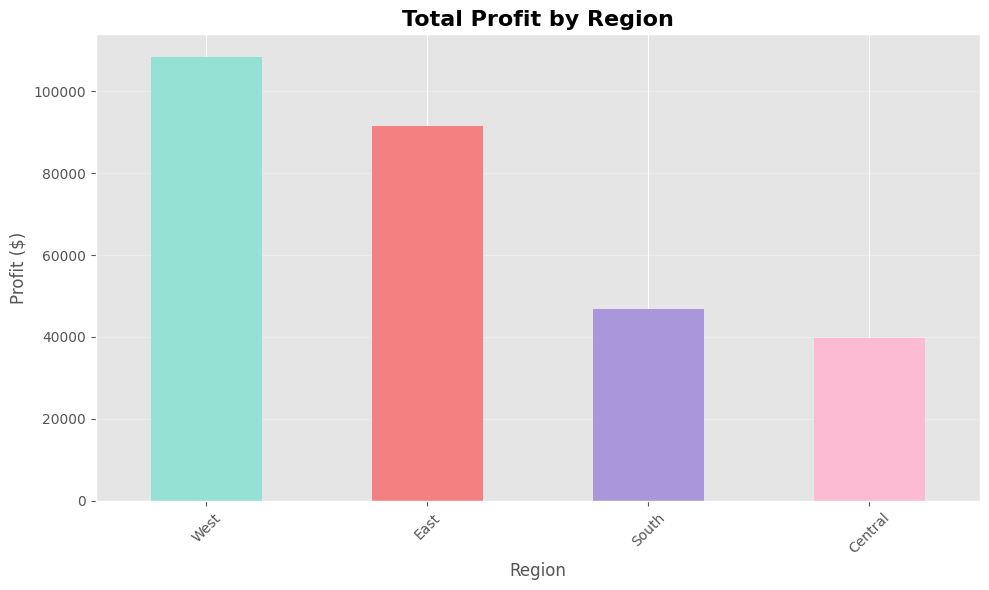

In [25]:
# Bar chart: Profit by Region
plt.figure(figsize=(10, 6))
profit_by_region.plot(kind='bar', color=['#95E1D3', '#F38181', '#AA96DA', '#FCBAD3'])
plt.title('Total Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

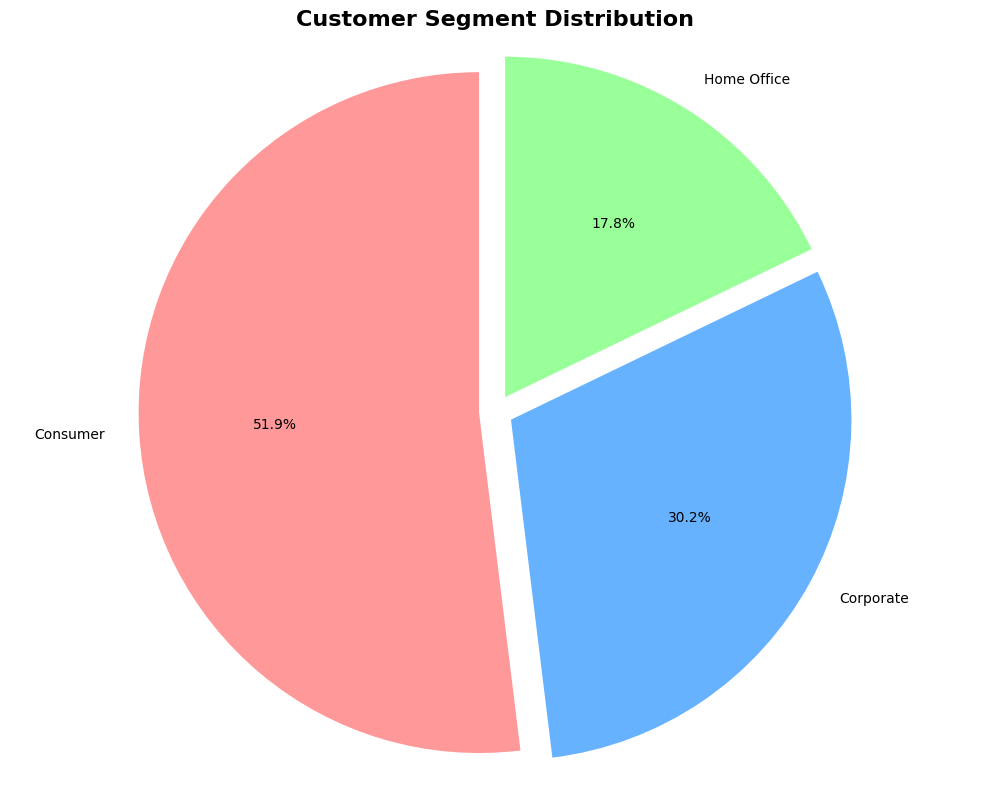

In [26]:
# Pie chart: Segment distribution
plt.figure(figsize=(10, 8))
segment_counts = df_cleaned['Segment'].value_counts()
colors = ['#FF9999', '#66B2FF', '#99FF99']
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=(0.05, 0.05, 0.05))
plt.title('Customer Segment Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Task 8: Insights & Analysis

In [27]:
# Most profitable category
profit_by_category = df_cleaned.groupby('Category')['Profit'].sum().sort_values(ascending=False)
most_profitable_category = profit_by_category.idxmax()

print("INSIGHTS & ANALYSIS")

print(f"\n1. Most Profitable Category: {most_profitable_category}")
print(f"   Profit: ${profit_by_category[most_profitable_category]:,.2f}")
print("\nProfit by Category:")
print(profit_by_category)

INSIGHTS & ANALYSIS

1. Most Profitable Category: Technology
   Profit: $145,454.95

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [28]:
# Least performing region
least_performing_region = profit_by_region.idxmin()
print(f"\n2. Least Performing Region: {least_performing_region}")
print(f"   Profit: ${profit_by_region[least_performing_region]:,.2f}")
print("\nProfit by Region (sorted):")
print(profit_by_region.sort_values())


2. Least Performing Region: Central
   Profit: $39,706.36

Profit by Region (sorted):
Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64



3. Patterns between Sales and Profit:

Correlation Matrix:
             Sales    Profit  Discount  Quantity
Sales     1.000000  0.479064 -0.028190  0.200795
Profit    0.479064  1.000000 -0.219487  0.066253
Discount -0.028190 -0.219487  1.000000  0.008623
Quantity  0.200795  0.066253  0.008623  1.000000


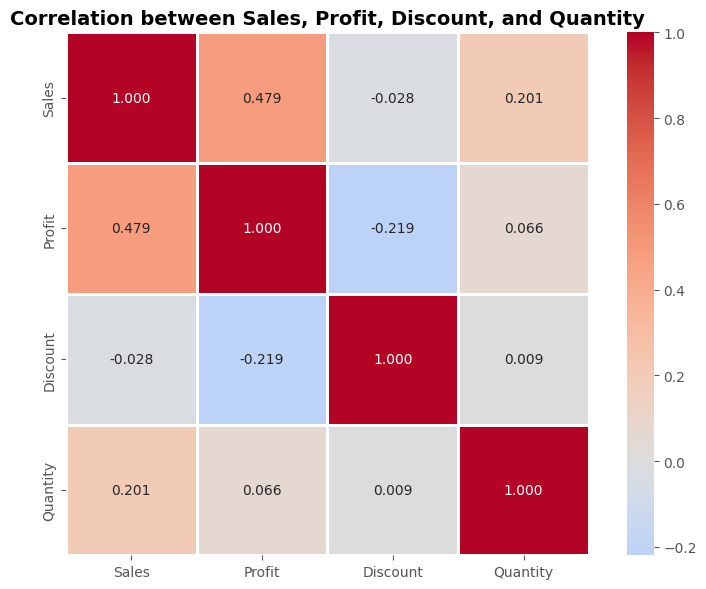


Key Findings:
- Sales vs Profit correlation: 0.479
- Discount vs Profit correlation: -0.219


In [29]:
# Patterns between sales and profit
print("\n3. Patterns between Sales and Profit:")
correlation = df_cleaned[['Sales', 'Profit', 'Discount', 'Quantity']].corr()
print("\nCorrelation Matrix:")
print(correlation)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation between Sales, Profit, Discount, and Quantity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nKey Findings:")
print(f"- Sales vs Profit correlation: {correlation.loc['Sales', 'Profit']:.3f}")
print(f"- Discount vs Profit correlation: {correlation.loc['Discount', 'Profit']:.3f}")

In [30]:
# Important trends over time
print("\n4. Important Trends Over Time:")

# Yearly trends
yearly_summary = df_cleaned.groupby('Order Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Number of Orders'})

yearly_summary['Profit Margin %'] = (yearly_summary['Profit'] / yearly_summary['Sales']) * 100
print("\nYearly Summary:")
print(yearly_summary)

# Calculate year-over-year growth
yearly_summary['Sales Growth %'] = yearly_summary['Sales'].pct_change() * 100
yearly_summary['Profit Growth %'] = yearly_summary['Profit'].pct_change() * 100
print("\nYear-over-Year Growth:")
print(yearly_summary[['Sales Growth %', 'Profit Growth %']])


4. Important Trends Over Time:

Yearly Summary:
                  Sales      Profit  Number of Orders  Profit Margin %
Order Year                                                            
2014        484247.4981  49543.9741              1993        10.231126
2015        470532.5090  61618.6037              2102        13.095504
2016        609205.5980  81795.1743              2587        13.426530
2017        733215.2552  93439.2696              3312        12.743771

Year-over-Year Growth:
            Sales Growth %  Profit Growth %
Order Year                                 
2014                   NaN              NaN
2015             -2.832227        24.371540
2016             29.471521        32.744284
2017             20.355962        14.235675


In [31]:
# Additional insights: Best and worst performing sub-categories
print("\n5. Additional Insights:")
subcategory_profit = df_cleaned.groupby('Sub-Category')['Profit'].sum().sort_values()
print("\nTop 5 Most Profitable Sub-Categories:")
print(subcategory_profit.tail(5))
print("\nTop 5 Least Profitable Sub-Categories:")
print(subcategory_profit.head(5))


5. Additional Insights:

Top 5 Most Profitable Sub-Categories:
Sub-Category
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

Top 5 Least Profitable Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64


In [32]:
# Impact of discount on profit
print("\n6. Impact of Discount on Profit:")
discount_analysis = df_cleaned.groupby('Discount Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Number of Orders'})
discount_analysis['Avg Profit per Order'] = discount_analysis['Profit'] / discount_analysis['Number of Orders']
print(discount_analysis)


6. Impact of Discount on Profit:
                          Sales       Profit  Number of Orders  \
Discount Category                                                
No Discount        1.087908e+06  320987.6032              4798   
Low                5.436935e+04    9029.1770                94   
Medium             7.921529e+05   91756.2975              3709   
High               3.627701e+05 -135376.0560              1393   

                   Avg Profit per Order  
Discount Category                        
No Discount                   66.900292  
Low                           96.055074  
Medium                        24.738824  
High                         -97.183098  


## Summary of Key Findings

In [33]:

print("SUMMARY OF KEY FINDINGS")
print(f"\n Dataset Overview:")
print(f"    Total Records: {len(df_cleaned):,}")
print(f"    Total Sales: ${df_cleaned['Sales'].sum():,.2f}")
print(f"    Total Profit: ${df_cleaned['Profit'].sum():,.2f}")
print(f"    Overall Profit Margin: {(df_cleaned['Profit'].sum() / df_cleaned['Sales'].sum() * 100):.2f}%")

print(f"\n Best Performers:")
print(f"    Most Profitable Category: {most_profitable_category}")
print(f"    Best Region: {profit_by_region.idxmax()}")
print(f"    Top Customer: {top_customers.idxmax()}")

print(f"\n  Areas of Concern:")
print(f"    Least Performing Region: {least_performing_region}")
print(f"    Worst Sub-Category: {subcategory_profit.idxmin()}")

print(f"\n Trends:")
print(f"    Sales show {'growth' if yearly_summary['Sales Growth %'].mean() > 0 else 'decline'} over time")
print(f"    Higher discounts correlate with {'lower' if correlation.loc['Discount', 'Profit'] < 0 else 'higher'} profit")


SUMMARY OF KEY FINDINGS

 Dataset Overview:
    Total Records: 9,994
    Total Sales: $2,297,200.86
    Total Profit: $286,397.02
    Overall Profit Margin: 12.47%

 Best Performers:
    Most Profitable Category: Technology
    Best Region: West
    Top Customer: Sean Miller

  Areas of Concern:
    Least Performing Region: Central
    Worst Sub-Category: Tables

 Trends:
    Sales show growth over time
    Higher discounts correlate with lower profit
